# TP1

In [ ]:
import pandas as pd
# Number of customers
customers = pd.read_csv('/content/customers.csv')
num_customers = customers['customer_id'].nunique()
num_customers

50000

In [ ]:
#Periode
customers['first_purchase'] = pd.to_datetime(customers['first_purchase'])
customers['last_purchase'] = pd.to_datetime(customers['last_purchase'])
period_customers = (min(customers['first_purchase'].min(), customers['last_purchase'].min()), max(customers['first_purchase'].max(), customers['last_purchase'].max()))
period_customers

(Timestamp('2007-05-18 12:20:00'), Timestamp('2011-12-09 12:20:00'))

In [ ]:
# valeurs manquantes
missing_customers = customers.isnull().sum()
missing_customers_prop = customers.isnull().mean()
missing_customers
missing_customers_prop

,0
customer_id,0.0
country,0.0
first_purchase,0.0
last_purchase,0.0
n_orders,0.0
total_spent,0.0
avg_basket,0.0
recency_days,0.0
tenure_days,0.0


In [ ]:
# Les types de données observés
dtypes_customers = customers.dtypes
dtypes_customers

,0
customer_id,int64
country,object
first_purchase,datetime64[ns]
last_purchase,datetime64[ns]
n_orders,float64
total_spent,float64
avg_basket,float64
recency_days,float64
tenure_days,float64


In [ ]:
#vérification des doublons
duplicates_customers = customers.duplicated().sum()
duplicates_customers

np.int64(0)

1. Métriques Globales

Nombre de clients : $50\,000$ profils uniques

Période couverte : Du 18 mai 2007 au 9 décembre 2011.

Aucune valeur manquanyte détectée, ni aucun doublon.

Total Customers: 50000
Date inconsistencies (swapped): 0

Metrics Statistics (Original):
        total_spent      n_orders    avg_basket
count  50000.000000  50000.000000  50000.000000
mean     421.538510      4.746364     65.428104
std     2014.135812      9.551931    139.874935
min        0.160000      0.850000      0.160000
25%       36.987500      1.060000     21.787500
50%       99.640000      2.220000     38.810000
75%      280.225000      5.210000     69.100000
90%      729.164000     10.181000    118.772000
99%     4995.519100     32.270100    513.882400
99.9%  26598.198910    151.809280   1596.180233
max    69630.660000    292.780000   5876.150000

Clipping Thresholds (99th percentile):
total_spent    4995.5191
n_orders         32.2701
avg_basket      513.8824
Name: 0.99, dtype: float64

Proportion One-time buyers (n_orders <= 1): 19.59%
Proportion Recurring customers (n_orders > 1): 80.41%


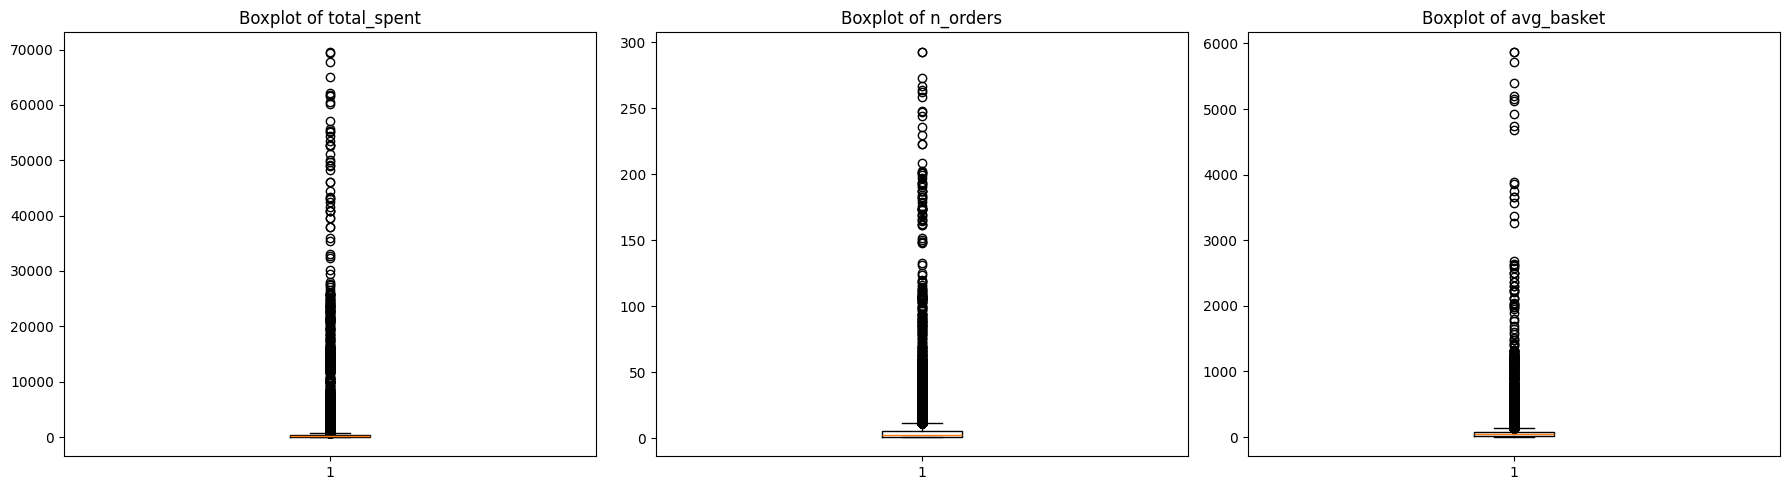

In [ ]:
import matplotlib.pyplot as plt

customers['first_purchase'] = pd.to_datetime(customers['first_purchase'])
customers['last_purchase'] = pd.to_datetime(customers['last_purchase'])

# 1. Date:  first_purchase <= last_purchase
inconsistent_dates_mask = customers['first_purchase'] > customers['last_purchase']
num_inconsistent = inconsistent_dates_mask.sum()

if num_inconsistent > 0:
    customers.loc[inconsistent_dates_mask, ['first_purchase', 'last_purchase']] = \
        customers.loc[inconsistent_dates_mask, ['last_purchase', 'first_purchase']].values

# 2. Outliers
metrics = ['total_spent', 'n_orders', 'avg_basket']
stats = customers[metrics].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99, 0.999])

clipping_thresholds = customers[metrics].quantile(0.99)
customers_clipped = customers.copy()
for m in metrics:
    customers_clipped[m] = customers_clipped[m].clip(upper=clipping_thresholds[m])

# 3. Proportion
single_mask = customers['n_orders'] <= 1
prop_single = single_mask.mean()
prop_recurring = 1 - prop_single

customers_clipped['n_orders'] = customers_clipped['n_orders'].round().astype(int)

# 4. Resultats
print(f"Total Customers: {len(customers)}")
print(f"Date inconsistencies (swapped): {num_inconsistent}")
print("\nMetrics Statistics (Original):")
print(stats)
print("\nClipping Thresholds (99th percentile):")
print(clipping_thresholds)
print(f"\nProportion One-time buyers (n_orders <= 1): {prop_single:.2%}")
print(f"Proportion Recurring customers (n_orders > 1): {prop_recurring:.2%}")

# Visualisation de la distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, m in enumerate(metrics):
    axes[i].boxplot(customers[m])
    axes[i].set_title(f'Boxplot of {m}')
plt.tight_layout()
plt.savefig('customers_outliers_pre.png')

customers_clipped.to_csv('customers_cleaned.csv', index=False)

# Analyse des anomalies
- Aucune anomalie détectée dans la cohérence des dates ( structure temporelle intègre)
- Outliers (total_spentMax) : $69\,630$ vs P99 : $4\,995$. Écart extrême.**Clipping** (écrêtage) au 99ème percentile ($4\,995$).Supprime l'effet "bruit" des clients atypiques (whales) qui fausseraient les moyennes de segmentation.
- Outliers (n_ordersMax : $292$ vs P99)  $32$. Présence de décimales.Arrondi à l'entier et Clipping au P99 ($32$).Un nombre de commandes est par nature entier. Le clipping stabilise la variance pour les modèles futurs.
- Outliersa(vg_basketMax) : $5\,876$ vs P99 : $513$.Clipping au 99ème percentile ($513$).Évite que quelques transactions massives ne dominent l'analyse du panier moyen.

On observe sur les boxplots ci-dessus une compression majeure des "boîtes" due à l'étalement extrême des valeurs aberrantes, confirmant la nécessité du clipping pour une segmentation efficace.

Résultat : 24.92% des clients génèrent 80% du chiffre d'affaires.


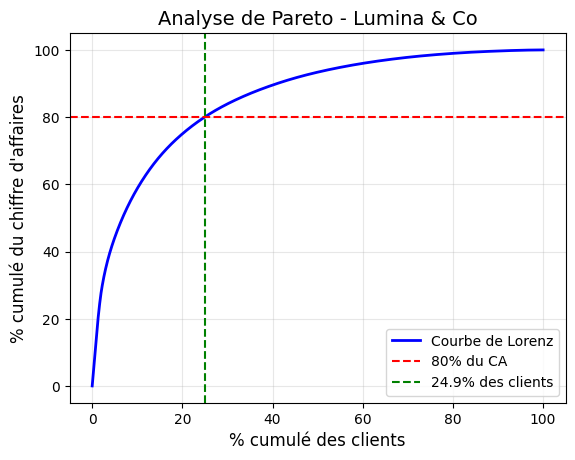

In [ ]:
#Proportion des clients qui génèrent 80% du chiffre d'affaires

#Préparation pour la Loi de Pareto
pareto_df = customers_clipped[['customer_id', 'total_spent']].sort_values(by='total_spent', ascending=False).reset_index(drop=True)

# Calcul des pourcentages cumulés
pareto_df['cum_revenue'] = pareto_df['total_spent'].cumsum()
total_revenue = pareto_df['total_spent'].sum()
pareto_df['cum_rev_pct'] = (pareto_df['cum_revenue'] / total_revenue) * 100
pareto_df['cum_cust_pct'] = (pareto_df.index + 1) / len(pareto_df) * 100

# Trouver le seuil des 80%
cust_pct_for_80_rev = pareto_df[pareto_df['cum_rev_pct'] >= 80].iloc[0]['cum_cust_pct']

# 3. Visualisation (Courbe de Lorenz)
plt.plot(pareto_df['cum_cust_pct'], pareto_df['cum_rev_pct'], label='Courbe de Lorenz', color='blue', lw=2)
plt.axhline(y=80, color='r', linestyle='--', label='80% du CA')
plt.axvline(x=cust_pct_for_80_rev, color='g', linestyle='--', label=f'{cust_pct_for_80_rev:.1f}% des clients')

plt.title('Analyse de Pareto - Lumina & Co', fontsize=14)
plt.xlabel('% cumulé des clients', fontsize=12)
plt.ylabel('% cumulé du chiffre d\'affaires', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('pareto_analysis_customers.png')

print(f"Résultat : {cust_pct_for_80_rev:.2f}% des clients génèrent 80% du chiffre d'affaires.")

# Résultats de l'analyse

- $24,92\%$ des clients génèrent $80\%$ du
 chiffre d'affaires total.

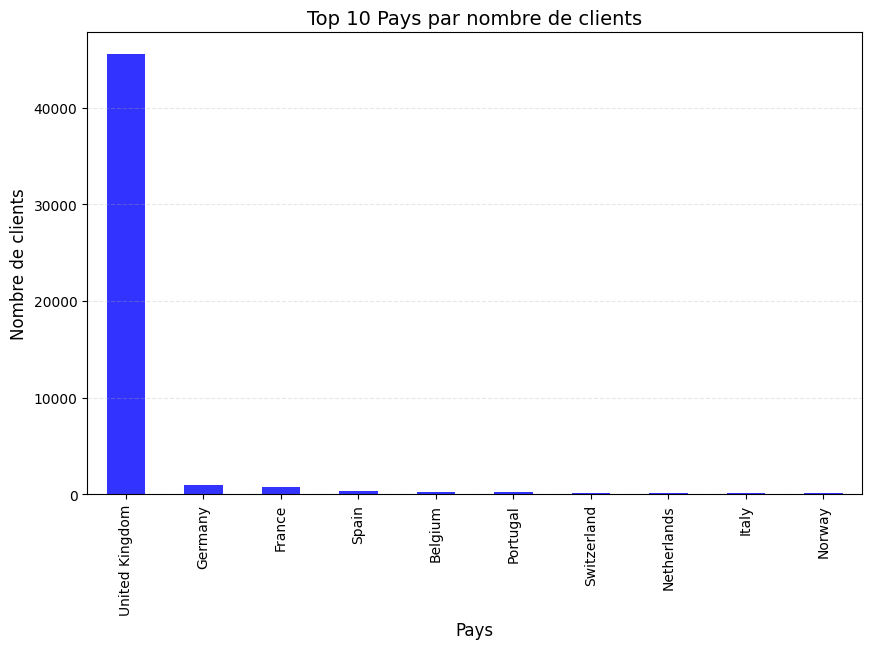

Biais constaté : Le pays dominant représente 91.0% de la base.


In [ ]:
# Analyse de distribution

customers['n_orders'] = customers['n_orders'].round().astype(int)
p99 = customers[['total_spent', 'avg_basket']].quantile(0.99)
customers['total_spent'] = customers['total_spent'].clip(upper=p99['total_spent'])

# Calcul de la distribution
country_counts = customers['country'].value_counts().head(10)

# Visualisation 1 : Top 10 Pays par nombre de clients
plt.figure(figsize=(10, 6))
country_counts.plot(kind='bar', color='blue', alpha=0.8) # Bleu Pareto

plt.title('Top 10 Pays par nombre de clients', fontsize=14)
plt.xlabel('Pays', fontsize=12)
plt.ylabel('Nombre de clients', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig('geo_distribution_count.png')
plt.show()

print(f"Biais constaté : Le pays dominant représente {(customers['country'] == 'United Kingdom').mean()*100:.1f}% de la base.")

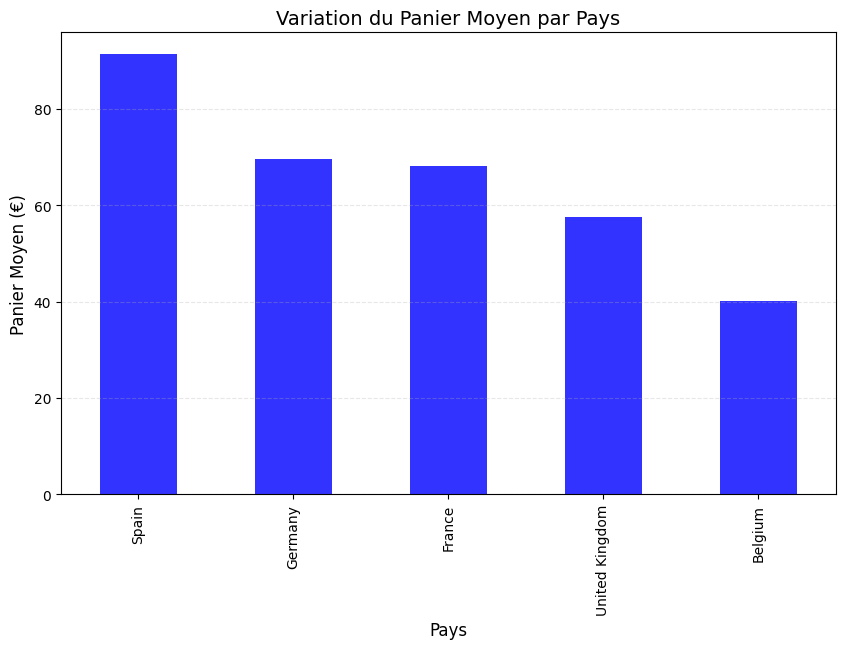

Moyennes du panier moyen :
country
Spain             91.264557
Germany           69.532850
France            68.100077
United Kingdom    57.515360
Belgium           40.073833
Name: avg_basket, dtype: float64


In [ ]:
# Variation panier moyen
# Identification des 5 pays majeurs
top_5_countries = customers_clipped['country'].value_counts().head(5).index
geo_basket = customers_clipped[customers_clipped['country'].isin(top_5_countries)].groupby('country')['avg_basket'].mean().sort_values(ascending=False)

# Visualisation : Panier Moyen
plt.figure(figsize=(10, 6))
geo_basket.plot(kind='bar', color='blue', alpha=0.8)

plt.title('Variation du Panier Moyen par Pays', fontsize=14)
plt.xlabel('Pays', fontsize=12)
plt.ylabel('Panier Moyen (€)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig('geo_variation_avg_basket.png')
plt.show()

print("Moyennes du panier moyen :")
print(geo_basket)


# Analyse

- Biais Géographique : Le Royaume-Uni (United Kingdom) représente $91\%$ des clients. Les segments marketing globaux seront donc majoritairement influencés par les habitudes britanniques.
- Variabilité : Bien que l'UK soit dominant en volume, des pays comme l'Espagne affichent un panier moyen nettement plus élevé ($91€$), suggérant un profil de clients "gros acheteurs" ou des frais de port incitant à des commandes groupées.

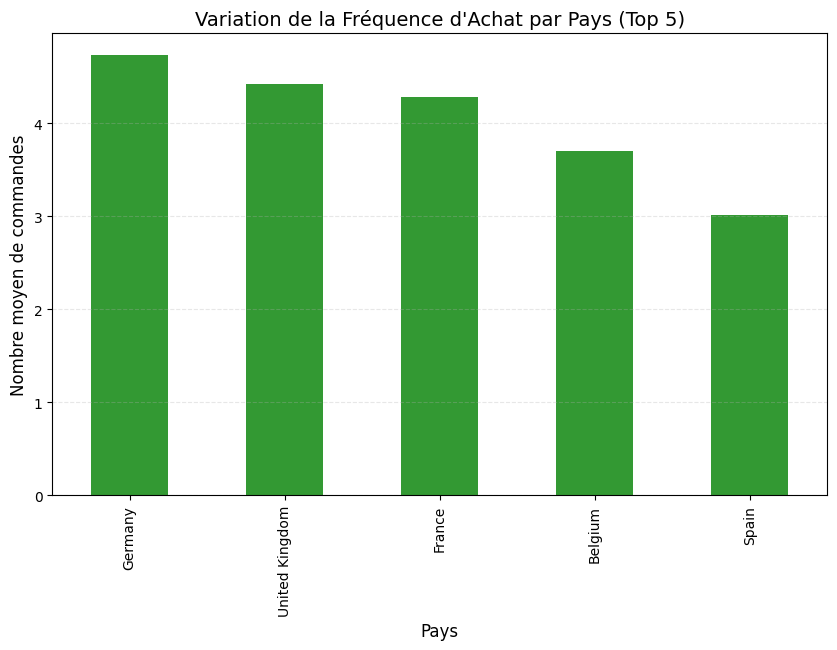

Moyennes de fréquence (commandes) :
country
Germany           4.732794
United Kingdom    4.422161
France            4.279614
Belgium           3.701068
Spain             3.012903
Name: n_orders, dtype: float64


In [ ]:
#Variation de la fréquence d'achat par pays

# Calcul de la fréquence moyenne (nombre de commandes)
geo_freq = customers_clipped[customers_clipped['country'].isin(top_5_countries)].groupby('country')['n_orders'].mean().sort_values(ascending=False)

# Visualisation : Fréquence
plt.figure(figsize=(10, 6))
geo_freq.plot(kind='bar', color='green', alpha=0.8)

plt.title('Variation de la Fréquence d\'Achat par Pays (Top 5)', fontsize=14)
plt.xlabel('Pays', fontsize=12)
plt.ylabel('Nombre moyen de commandes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig('geo_variation_frequency.png')
plt.show()

print("Moyennes de fréquence (commandes) :")
print(geo_freq)

# Analyse

- L'allemagne représente le marché européen le plus performant après le UK, combinant une forte fréquence ($4,73$) et un panier moyen élevé.
- Les clients espagnols ont le panier moyen le plus élevé ($91€$) mais la fréquence la plus basse ($3$ commandes). Ils groupent probablement leurs achats pour amortir des frais de livraison plus élevés.
- L'Allemagne combine un panier moyen élevé ($70€$) et la meilleure fidélité ($4,7$ commandes).
- Le marché britanique est dominant en nombre de clients, il se situe dans la moyenne basse pour le panier moyen ($57€$), suggérant une utilisation plus "quotidienne" ou de proximité


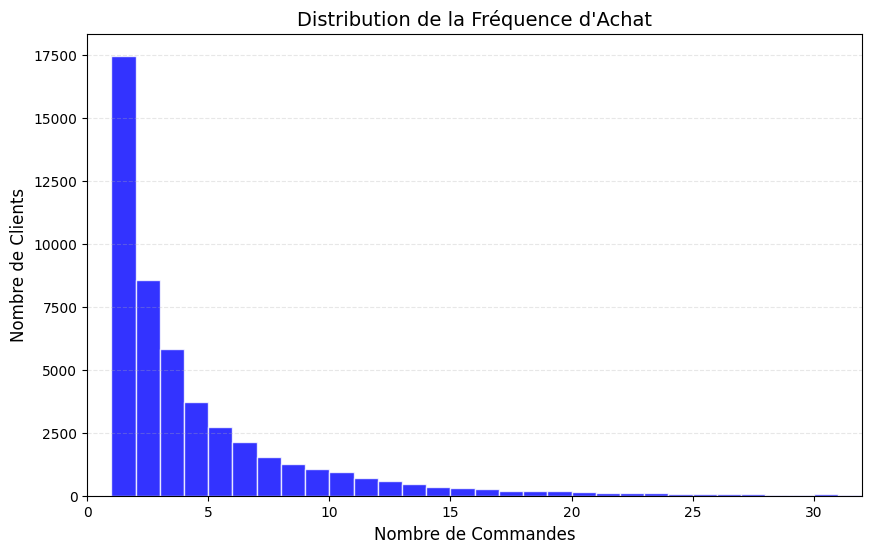

In [ ]:
# 1. Préparation des données (Arrondi CRM et focus sur 99% de la base)
customers['n_orders_rounded'] = customers['n_orders'].round().astype(int)
p99_freq = customers['n_orders_rounded'].quantile(0.99)

# 2. Visualisation de la distribution
plt.figure(figsize=(10, 6))
plt.hist(customers['n_orders_rounded'], bins=range(1, int(p99_freq) + 2),
         color='blue', alpha=0.8, edgecolor='white')

plt.title('Distribution de la Fréquence d\'Achat', fontsize=14)
plt.xlabel('Nombre de Commandes', fontsize=12)
plt.ylabel('Nombre de Clients', fontsize=12)
plt.xlim(0, p99_freq)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig('frequency_distribution.png')
plt.show()

# Analyse

- Un achat unique (34,95%) : Plus d'un tiers des clients n'ont commandé qu'une seule fois.
- Occasionnels [2-5] (41,69%) : Le groupe le plus important. Ils ont dépassé le premier achat et constituent le moteur de croissance.
- Réguliers [6-15] (18,69%) : Près de 20% des clients sont installés dans une routine d'achat régulière.
- Ambassadeurs [>15] (4,66%) : Les clients fidèles. Bien que peu nombreux, ce sont eux qui stabilisent votre chiffre d'affaires (et qui sont probablement dans le top 20% de Pareto).

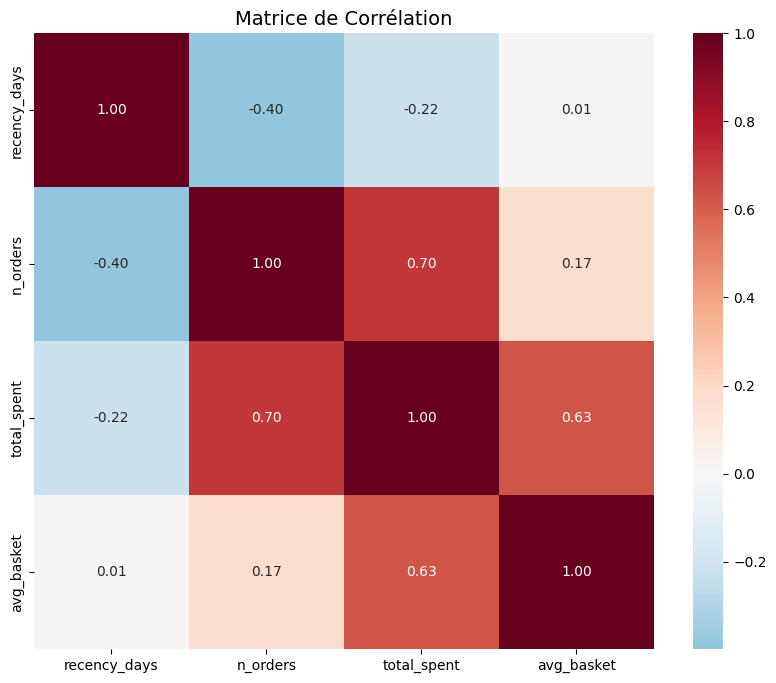

In [ ]:
# Corrélation entre les variables
import seaborn as sns
# Calcul de la matrice de corrélation
corr_matrix = customers_clipped[['recency_days', 'n_orders', 'total_spent', 'avg_basket']].corr()

# Visualisation 1 : Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Matrice de Corrélation', fontsize=14)
plt.savefig('correlation_heatmap.png')
plt.show()

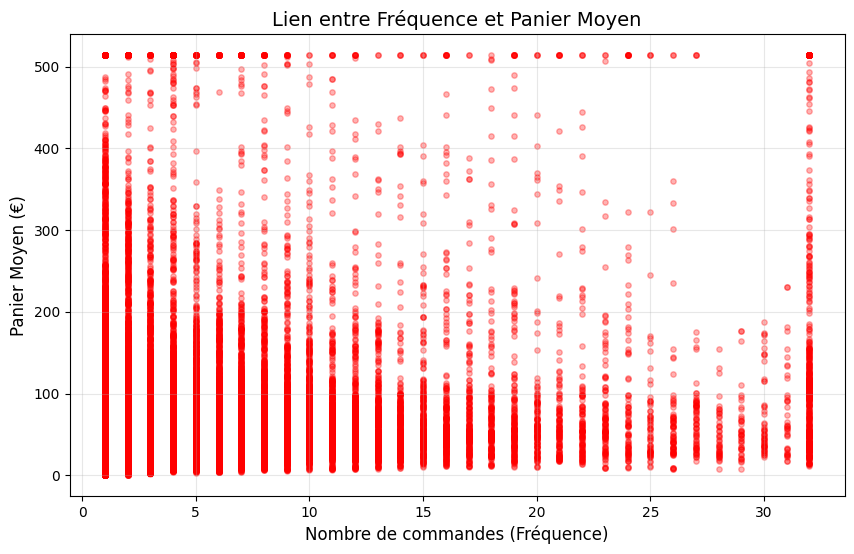

In [ ]:
# Visualisation 2 : Scatter plot n_orders vs avg_basket
plt.figure(figsize=(10, 6))
plt.scatter(customers_clipped['n_orders'], customers_clipped['avg_basket'], alpha=0.3, color='red', s=15)

plt.title('Lien entre Fréquence et Panier Moyen', fontsize=14)
plt.xlabel('Nombre de commandes (Fréquence)', fontsize=12)
plt.ylabel('Panier Moyen (€)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('rel_frequency_vs_avg_basket.png')
plt.show()

# Analyse

- Relation Récence / Fréquence ($-0,40$) : Il existe une corrélation négative modérée. Plus le client est ancien, moins il a tendance à avoir cumulé de commandes. C'est le signe d'une base où les clients récents sont les plus actifs.
- Fréquence / Montant Total ($0,70$) : C'est la corrélation la plus forte. La valeur totale d'un client est principalement dictée par son nombre de visites plutôt que par la taille de son panier.
- L'indépendance du Panier Moyen : Le scatter plot montre une corrélation très faible ($0,17$) entre le nombre de commandes et le panier moyen.

Les clients fidèles n'augmentent pas forcément leur panier moyen au fil du temps. Ils achètent plus souvent, mais pas plus gros.

# Formulation des hypothèses marketing

1. La très faible corrélation ($0,17) entre la fréquence d'achat et le montant du panier moyen implique que les clients fidèles achètent par habitude sans augmenter la valeur de leur commande au fil du temps, ce qui suggère de tester des mécaniques de Bundling (lots) ou des recommandations de produits complémentaires (Cross-sell) spécifiquement pour les clients ayant déjà plus de 5 commandes.

2. La présence de 35% de clients n'ayant effectué qu'un seul achat implique une difficulté majeure à transformer l'essai après la première transaction, ce qui suggère une campagne d'automation Post-Achat envoyant un coupon de réduction valable 30 jours immédiatement après la première commande pour inciter au second achat.

3. L'hypothèse Espagne (panier moyen le plus élevé mais fréquence basse) implique que ces clients groupent massivement leurs achats pour rentabiliser des frais de livraison élevés, ce qui suggère de proposer une offre de livraison "Premium" illimitée à l'année pour encourager une fréquence d'achat plus fluide et régulière sur ce marché.

4. Les clients identifiés à fort montant total mais à récence élevée ($> 300$ jours) implique un risque de perte définitive (churn) de clients autrefois piliers, ce qui suggère une campagne de reconquête par e-mail direct ou appel prioritaire, proposant un cadeau de bon retour pour réactiver leur cycle d'achat.

# TP3

In [ ]:
df = pd.read_csv('transactions.csv', on_bad_lines='skip', low_memory=False)

# Nettoyage des colonnes numériques (conversion forcée, les textes deviennent NaN)
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')
df['customer_id'] = pd.to_numeric(df['customer_id'], errors='coerce')
df['invoice_date'] = pd.to_datetime(df['invoice_date'], errors='coerce')

# Suppression des lignes inutilisables pour un modèle CLV
df = df.dropna(subset=['customer_id', 'quantity', 'unit_price', 'invoice_date'])

# Calcul du montant de la ligne (nettoyé)
df['line_total'] = df['quantity'] * df['unit_price']

# 2. Split Temporel (12m / 12m)
max_date = df['invoice_date'].max()
split_date = max_date - pd.DateOffset(months=12)
start_date = split_date - pd.DateOffset(months=12)

obs_period = df[(df['invoice_date'] >= start_date) & (df['invoice_date'] < split_date)].copy()
target_period = df[(df['invoice_date'] >= split_date) & (df['invoice_date'] <= max_date)].copy()

print(f"Split effectué au {split_date.date()}")

# 3. Étape 2 : Feature Engineering (Période d'Observation)
def extract_features(group):
    # RFM de base
    total_spent = group['line_total'].sum()
    n_orders = group['invoice_id'].nunique()
    last_date = group['invoice_date'].max()
    first_date = group['invoice_date'].min()

    # Comportemental
    n_unique_products = group['product_code'].nunique()

    # Régularité (écart-type des jours entre achats)
    if n_orders > 1:
        order_dates = group.groupby('invoice_id')['invoice_date'].first().sort_values()
        days_between = order_dates.diff().dt.days.dropna()
        regularity = days_between.std()
    else:
        regularity = 0 # Pas de régularité mesurable pour 1 seul achat

    return pd.Series({
        'obs_total_spent': total_spent,
        'obs_n_orders': n_orders,
        'obs_recency': (split_date - last_date).days,
        'obs_avg_basket': total_spent / n_orders,
        'obs_tenure': (split_date - first_date).days,
        'obs_n_unique_products': n_unique_products,
        'obs_regularity': regularity,
        'obs_start_month': first_date.month
    })

print("Calcul des features (ceci peut prendre 1-2 minutes)...")
features = obs_period.groupby('customer_id').apply(extract_features)

# 4. Étape 1 : Création de la Target (Période Cible)
target = target_period.groupby('customer_id')['line_total'].sum().rename('target_clv_12m')

# 5. Assemblage final
dataset_clv = features.join(target).fillna(0)

dataset_clv.to_csv('clv_final_matrix.csv')
print("Fichier prêt : clv_final_matrix.csv")

Split effectué au 2010-12-09
Calcul des features (ceci peut prendre 1-2 minutes)...


/tmp/ipython-input-1047/2318266104.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features = obs_period.groupby('customer_id').apply(extract_features)


Fichier prêt : clv_final_matrix.csv


In [ ]:
import pandas as pd
import numpy as np

# --- ÉTAPE 2 : FEATURE ENGINEERING ---

def build_features(group):
    # 1. Base RFM (Observation)
    total_spent = group['line_total'].sum()
    n_orders = group['invoice_id'].nunique()
    last_date = group['invoice_date'].max()
    first_date = group['invoice_date'].min()

    # 2. Comportemental : Diversité et Régularité
    n_categories = group['product_code'].astype(str).str[:2].nunique()

    # Écart-type des délais inter-achats (Régularité)
    if n_orders > 1:
        order_dates = group.groupby('invoice_id')['invoice_date'].first().sort_values()
        regularity = order_dates.diff().dt.days.dropna().std()
    else:
        regularity = 0

    # 3. Saisonnalité : Proportion d'achats sur les mois de pic (ex: Oct, Nov, Dec)
    peak_months = [10, 11, 12]
    peak_spent = group[group['invoice_date'].dt.month.isin(peak_months)]['line_total'].sum()
    peak_ratio = peak_spent / total_spent if total_spent > 0 else 0

    # 4. Tendance : Dépense 6 derniers mois vs 6 premiers mois de l'obs
    # Calcul basé sur la médiane de la période d'observation
    mid_obs = obs_period['invoice_date'].min() + pd.DateOffset(months=6)
    spent_h1 = group[group['invoice_date'] < mid_obs]['line_total'].sum()
    spent_h2 = group[group['invoice_date'] >= mid_obs]['line_total'].sum()
    trend = spent_h2 - spent_h1

    # 5. Temporel : Ancienneté et Intensité
    tenure = (split_date - first_date).days
    n_months_active = group['invoice_date'].dt.to_period('M').nunique()

    return pd.Series({
        'recency': (split_date - last_date).days,
        'frequency': n_orders,
        'monetary': total_spent,
        'avg_basket': total_spent / n_orders,
        'n_categories': n_categories,
        'regularity': regularity,
        'peak_ratio': peak_ratio,
        'trend': trend,
        'tenure': tenure,
        'start_month': first_date.month,
        'n_months_active': n_months_active
    })

print("Extraction des features comportementales par client...")
X = obs_period.groupby('customer_id').apply(build_features)

# 6. Géographie : Encodage des Pays (Top 5 identifiés en J1)
# On récupère le pays via le mapping de l'index sur cust_base (chargé en Étape 1)
top_countries = ['United Kingdom', 'Germany', 'France', 'EIRE', 'Spain']
for country in top_countries:
    col_name = f'is_{country.replace(" ", "_")}'
    X[col_name] = X.index.map(customers.set_index('customer_id')['country'])
    X[col_name] = (X[col_name] == country).astype(int)

# Remplacement des éventuelles valeurs manquantes par 0
X = X.fillna(0)

print(f"Feature engineering terminé. Matrice X : {X.shape[0]} clients x {X.shape[1]} variables.")

Extraction des features comportementales par client...
Feature engineering terminé. Matrice X : 29120 clients x 16 variables.


/tmp/ipython-input-1047/1949220892.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  X = obs_period.groupby('customer_id').apply(build_features)


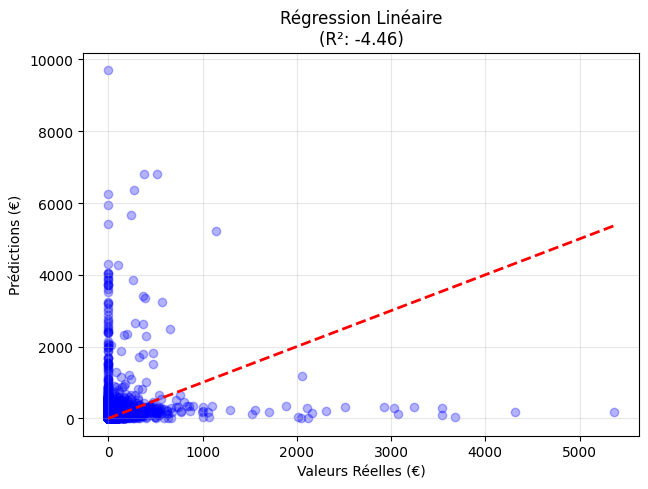


--- Synthèse des Performances ---
Régression Linéaire: MAE = 166.70€ | RMSE = 451.02€ | R² = -4.4630


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Préparation des matrices
# On suppose que 'target_clv_12m' est dans votre DataFrame final
y = dataset_clv['target_clv_12m']
X = dataset_clv.drop(columns=['target_clv_12m'])

# 2. Split temporel (shuffle=False)
# On garde les 20% derniers clients (souvent les plus récents) pour le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 3. Initialisation des modèles
models = {
    "Régression Linéaire": LinearRegression(),
    #"Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    #"XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

# 4. Entraînement et Évaluation
results = {}

plt.figure(figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    # Entraînement
    model.fit(X_train, y_train)

    # Prédiction
    y_pred = model.predict(X_test)
    y_pred = np.maximum(y_pred, 0) # La CLV ne peut pas être négative

    # Métriques
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2}

    # 5. Visualisation : Réel vs Prédit
    plt.subplot(1, 3, i+1)
    plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
    plt.title(f"{name}\n(R²: {r2:.2f})")
    plt.xlabel("Valeurs Réelles (€)")
    plt.ylabel("Prédictions (€)")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Affichage des scores
print("\n--- Synthèse des Performances ---")
for name, metrics in results.items():
    print(f"{name}: MAE = {metrics['MAE']:.2f}€ | RMSE = {metrics['RMSE']:.2f}€ | R² = {metrics['R²']:.4f}")

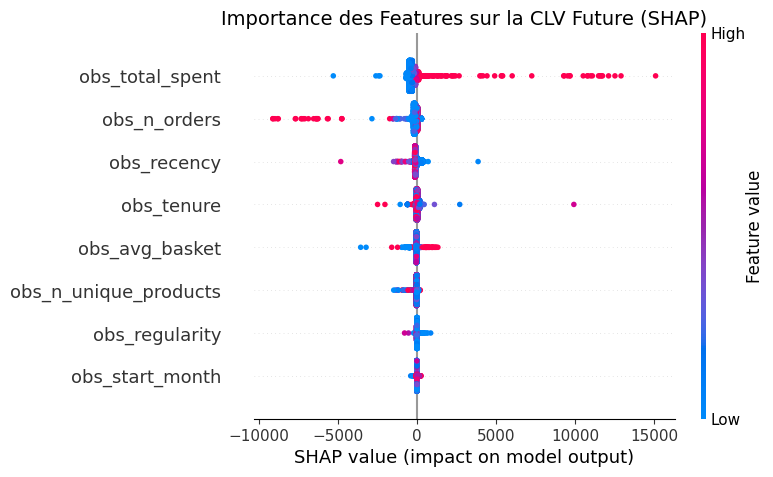

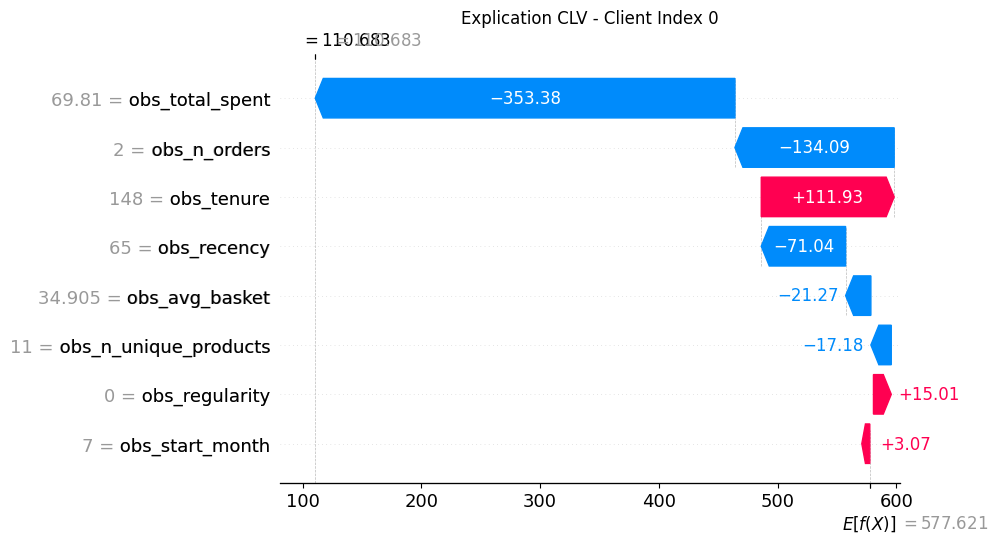

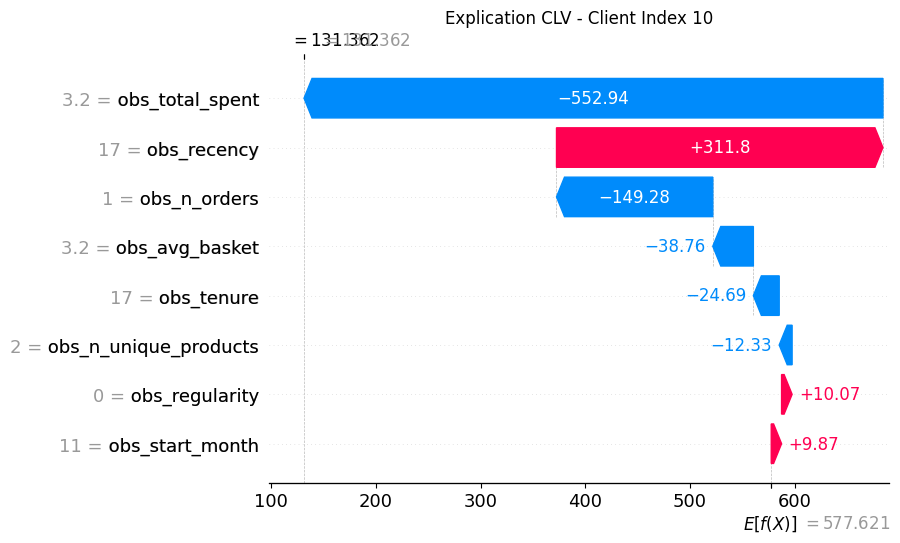

In [ ]:
import shap

# 1. Initialisation de l'explainer SHAP
# On utilise le modèle XGBoost entraîné à l'étape 3
explainer = shap.TreeExplainer(models["XGBoost"])
shap_values = explainer.shap_values(X_test)

# 2. Importance globale : Beeswarm Plot
# Ce graphique montre quelles variables tirent la CLV vers le haut ou vers le bas
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title("Importance des Features sur la CLV Future (SHAP)", fontsize=14)
plt.savefig("clv_shap_beeswarm.png")
plt.show()

# 3. Analyse individuelle : Pourquoi ce client ?
# On prend 2 exemples : un client à forte CLV et un à faible CLV
indices_interet = [0, 10] # À adapter selon vos résultats de test

for idx in indices_interet:
    plt.figure()
    shap.plots.waterfall(explainer(X_test)[idx], show=False)
    plt.title(f"Explication CLV - Client Index {idx}")
    plt.show()

In [ ]:
# 1. Création du DataFrame de résultats sur le test set
results_analysis = X_test.copy()
results_analysis['clv_predicted'] = y_pred
results_analysis['clv_actual'] = y_test.values

# 2. Division en déciles (10 groupes de taille égale)
# Le décile 10 contient les 10% de clients avec la plus forte CLV prédite
results_analysis['clv_decile'] = pd.qcut(results_analysis['clv_predicted'], 10, labels=False) + 1

# 3. Caractérisation des segments
# On compare les moyennes RFM par décile pour comprendre qui ils sont
decile_summary = results_analysis.groupby('clv_decile').agg({
    'clv_predicted': 'mean',
    'clv_actual': 'mean',
    'obs_total_spent': 'mean',   # Dépense passée
    'obs_n_orders': 'mean',  # Nombre de commandes passées
    'obs_recency': 'mean'     # Jours d'inactivité
}).round(2)

print("--- Analyse par Déciles de CLV Prédite ---")
print(decile_summary)

# 4. Challenge : Calcul du ROI de la campagne de rétention
# Hypothèses : Coût = 2€/client, Lift = 15% sur la valeur prédite
top_10_percent = results_analysis[results_analysis['clv_decile'] == 10]

n_clients = len(top_10_percent)
total_cost = n_clients * 2
# Le gain est le CA additionnel généré par le lift de 15%
predicted_revenue_top10 = top_10_percent['clv_predicted'].sum()
additional_revenue = predicted_revenue_top10 * 0.15

roi = (additional_revenue - total_cost) / total_cost

print("\n--- Simulation ROI (Ciblage Top 10% CLV) ---")
print(f"Nombre de clients ciblés : {n_clients}")
print(f"Coût total de la campagne : {total_cost:.2f}€")
print(f"Chiffre d'affaires additionnel attendu (Lift 15%) : {additional_revenue:.2f}€")
print(f"ROI Potentiel : {roi * 100:.2f}%")

--- Analyse par Déciles de CLV Prédite ---
            clv_predicted  clv_actual  obs_total_spent  obs_n_orders  \
clv_decile                                                             
1               18.160000        9.32            85.49          1.06   
2               37.820000       33.31            36.19          1.01   
3               47.939999       35.56            50.55          1.19   
4               72.570000       29.93            54.49          1.77   
5               97.510002       21.41            65.11          1.73   
6              128.559998       47.58            78.76          1.78   
7              166.440002       33.64           102.17          2.23   
8              228.449997       46.34           183.12          2.41   
9              311.489990       67.56           320.33          2.64   
10             715.150024       88.94           908.23          5.26   

            obs_recency  
clv_decile               
1                287.01  
2             